# 05 — Evaluación Final, Selección del Modelo y Casos de Predicción
**Proyecto:** PredictRent — Predicción de precios de alquiler en Lima Metropolitana  
**Objetivo:** Evaluar todos los modelos en el conjunto de test (datos nunca vistos), seleccionar el modelo final con justificación, y analizar casos reales de predicción.

---
## Índice
1. Carga de modelos y datos
2. Evaluación final en Test
3. Análisis de residuos
4. Selección del modelo final — justificación
5. Casos de predicción — análisis individual
6. Análisis de errores sistemáticos
7. Casos previos del modelo en la literatura
8. Conclusiones y próximos pasos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
PROCESSED = '../data/processed/'
MODELS    = '../models/'
FIGURES   = '../reports/figures/'

# Cargar datos
X_train    = pd.read_csv(f'{PROCESSED}X_train.csv')
X_val      = pd.read_csv(f'{PROCESSED}X_val.csv')
X_test     = pd.read_csv(f'{PROCESSED}X_test.csv')
X_train_sc = np.load(f'{PROCESSED}X_train_sc.npy')
X_val_sc   = np.load(f'{PROCESSED}X_val_sc.npy')
X_test_sc  = np.load(f'{PROCESSED}X_test_sc.npy')
y_train    = pd.read_csv(f'{PROCESSED}y_train.csv')['log_precio'].values
y_val      = pd.read_csv(f'{PROCESSED}y_val.csv')['log_precio'].values
y_test     = pd.read_csv(f'{PROCESSED}y_test.csv')['log_precio'].values
FEATURES   = joblib.load(f'{MODELS}feature_names.joblib')

# Cargar modelos
lr    = joblib.load(f'{MODELS}01_linear_regression.joblib')
ridge = joblib.load(f'{MODELS}02_ridge.joblib')
lasso = joblib.load(f'{MODELS}03_lasso.joblib')
rf    = joblib.load(f'{MODELS}04_random_forest.joblib')
xgb   = joblib.load(f'{MODELS}05_xgboost.joblib')

# Dataset original limpio (para recuperar contexto de los listings)
df_orig = pd.read_csv(f'{PROCESSED}inmuebles_clean_v1.csv')

print(' Todo cargado correctamente')
print(f'Test set: {X_test.shape[0]} listings')

 Todo cargado correctamente
Test set: 503 listings


---
## 2. Evaluación final en Test

In [2]:
def evaluar_completo(modelo, X, y_log):
    y_pred_log = modelo.predict(X)
    y_real = np.expm1(y_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    return {
        'rmse': np.sqrt(mean_squared_error(y_real, y_pred)),
        'mae' : mean_absolute_error(y_real, y_pred),
        'mape': np.mean(np.abs((y_real - y_pred) / y_real)) * 100,
        'r2'  : r2_score(y_real, y_pred),
        'y_real': y_real,
        'y_pred': y_pred,
        'residuos': y_real - y_pred
    }

modelos_info = [
    ('Linear Regression', lr,    X_train_sc, X_val_sc, X_test_sc),
    ('Ridge',             ridge, X_train_sc, X_val_sc, X_test_sc),
    ('Lasso',             lasso, X_train_sc, X_val_sc, X_test_sc),
    ('Random Forest',     rf,    X_train,    X_val,    X_test),
    ('XGBoost',           xgb,   X_train,    X_val,    X_test),
]

resultados_test = []
preds_por_modelo = {}

print(f"{'Modelo':<22} {'RMSE':>10} {'MAE':>10} {'MAPE':>8} {'R²':>8}  {'Δ MAPE val→test':>16}")
print('-' * 80)

res_val = pd.read_csv(f'{PROCESSED}resultados_modelos.csv').set_index('modelo')

for nombre, modelo, X_tr, X_va, X_te in modelos_info:
    m = evaluar_completo(modelo, X_te, y_test)
    preds_por_modelo[nombre] = m
    delta_mape = m['mape'] - res_val.loc[nombre, 'val_mape'] if nombre in res_val.index else 0
    print(f"{nombre:<22} ${m['rmse']:>9,.0f} ${m['mae']:>9,.0f} {m['mape']:>7.2f}% {m['r2']:>8.4f}  {delta_mape:>+.2f}pp")
    resultados_test.append({'modelo': nombre, 'test_rmse': m['rmse'], 'test_mae': m['mae'],
                            'test_mape': m['mape'], 'test_r2': m['r2']})

res_test_df = pd.DataFrame(resultados_test).sort_values('test_r2', ascending=False)

Modelo                       RMSE        MAE     MAPE       R²   Δ MAPE val→test
--------------------------------------------------------------------------------
Linear Regression      $      474 $      294   33.16%   0.6619  +16.27pp
Ridge                  $      440 $      193   19.19%   0.7085  +2.31pp
Lasso                  $      439 $      189   18.19%   0.7104  +1.22pp
Random Forest          $      378 $      173   15.92%   0.7848  -0.61pp
XGBoost                $      355 $      183   19.00%   0.8106  +3.22pp


In [3]:
# Tabla unificada: val vs test para cada modelo
res_val_df = pd.read_csv(f'{PROCESSED}resultados_modelos.csv')
tabla_completa = res_val_df.merge(res_test_df, on='modelo')

print('\n=== TABLA COMPARATIVA COMPLETA: VALIDACIÓN vs TEST ===')
cols = ['modelo', 'val_r2', 'test_r2', 'val_mape', 'test_mape', 'val_rmse', 'test_rmse']
print(tabla_completa[cols].sort_values('test_r2', ascending=False).to_string(index=False, float_format='%.4f'))


=== TABLA COMPARATIVA COMPLETA: VALIDACIÓN vs TEST ===
           modelo  val_r2  test_r2  val_mape  test_mape  val_rmse  test_rmse
          XGBoost  0.8501   0.8106   15.7786    18.9971  292.7273   354.6705
    Random Forest  0.8412   0.7848   16.5246    15.9168  301.3483   378.0076
            Lasso  0.8494   0.7104   16.9630    18.1872  293.4816   438.5164
            Ridge  0.8493   0.7085   16.8851    19.1905  293.5902   439.9631
Linear Regression  0.8623   0.6619   16.8897    33.1612  280.5676   473.8194


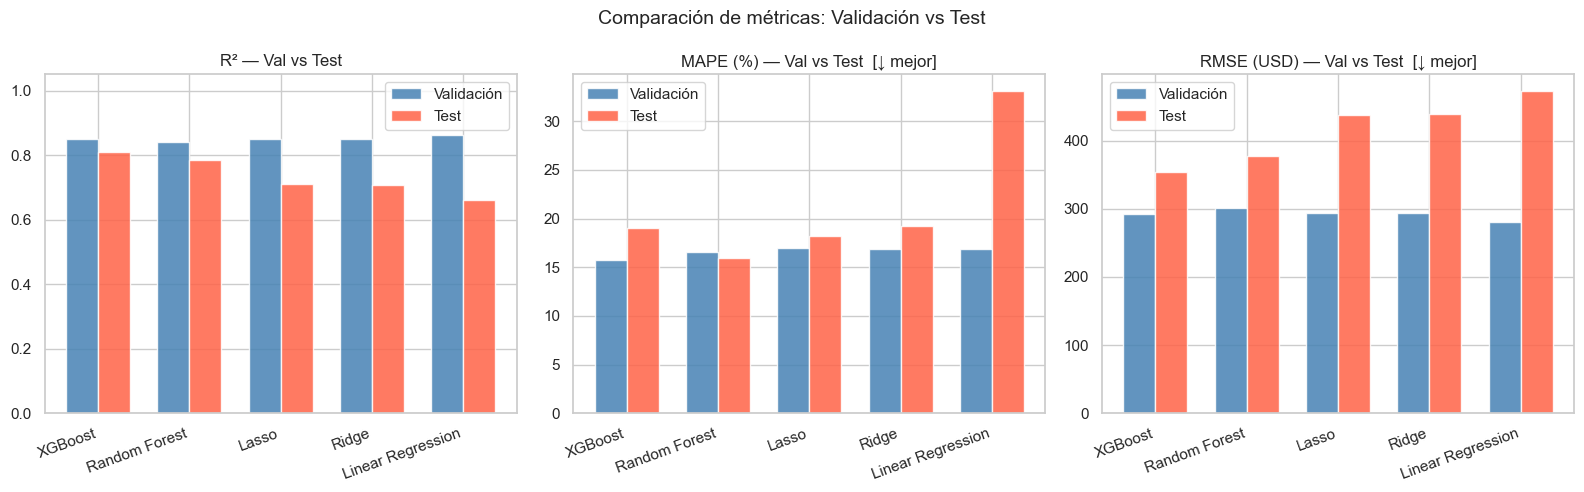

In [4]:
# Gráfico comparativo val vs test
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tabla_sorted = tabla_completa.sort_values('test_r2', ascending=False)
x = np.arange(len(tabla_sorted))
w = 0.35

# R²
axes[0].bar(x - w/2, tabla_sorted['val_r2'],  w, label='Validación', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, tabla_sorted['test_r2'], w, label='Test',       color='tomato',    alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(tabla_sorted['modelo'], rotation=20, ha='right')
axes[0].set_title('R² — Val vs Test'); axes[0].legend(); axes[0].set_ylim(0, 1.05)

# MAPE
axes[1].bar(x - w/2, tabla_sorted['val_mape'],  w, label='Validación', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, tabla_sorted['test_mape'], w, label='Test',       color='tomato',    alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(tabla_sorted['modelo'], rotation=20, ha='right')
axes[1].set_title('MAPE (%) — Val vs Test  [↓ mejor]'); axes[1].legend()

# RMSE
axes[2].bar(x - w/2, tabla_sorted['val_rmse'],  w, label='Validación', color='steelblue', alpha=0.85)
axes[2].bar(x + w/2, tabla_sorted['test_rmse'], w, label='Test',       color='tomato',    alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(tabla_sorted['modelo'], rotation=20, ha='right')
axes[2].set_title('RMSE (USD) — Val vs Test  [↓ mejor]'); axes[2].legend()

plt.suptitle('Comparación de métricas: Validación vs Test', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES}05_val_vs_test.png', dpi=150)
plt.show()

---
## 3. Análisis de residuos

Los residuos (error = precio_real - precio_predicho) revelan patrones que las métricas agregadas ocultan. Un buen modelo debe tener residuos distribuidos aleatoriamente alrededor de 0.

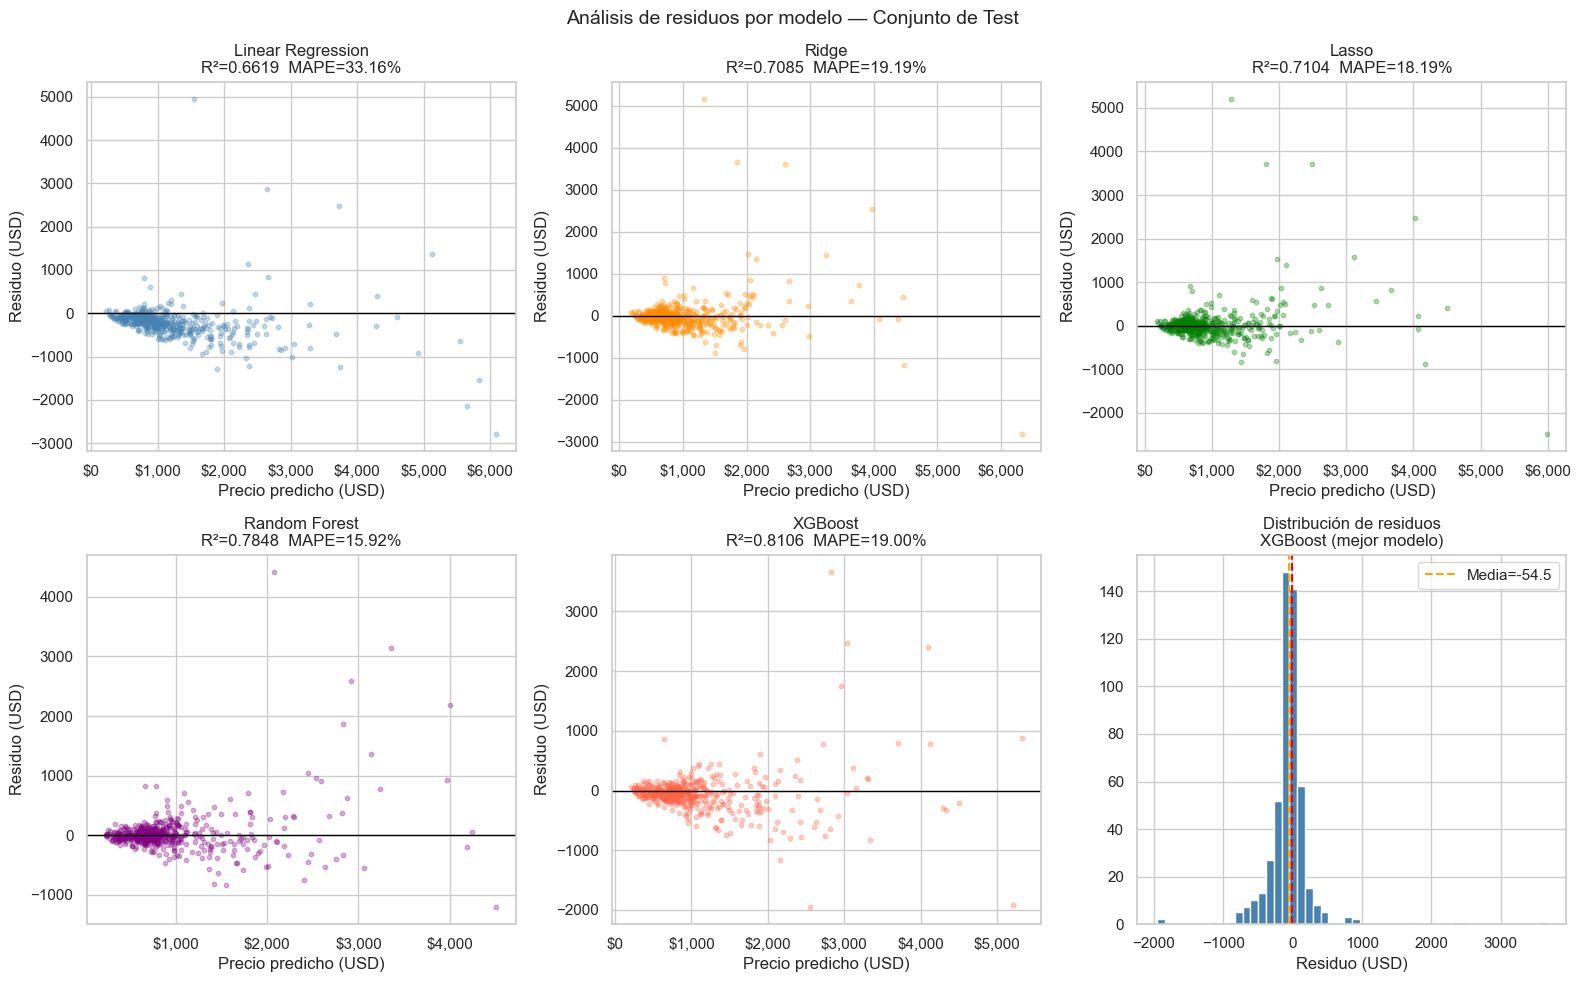

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colores = ['steelblue', 'darkorange', 'green', 'purple', 'tomato']
nombres = list(preds_por_modelo.keys())

for i, (nombre, color) in enumerate(zip(nombres, colores)):
    m = preds_por_modelo[nombre]
    ax = axes[i]
    ax.scatter(m['y_pred'], m['residuos'], alpha=0.3, s=10, color=color)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{nombre}\nR²={m["r2"]:.4f}  MAPE={m["mape"]:.2f}%')
    ax.set_xlabel('Precio predicho (USD)')
    ax.set_ylabel('Residuo (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Último panel: distribución de residuos del mejor modelo
best_name = res_test_df.iloc[0]['modelo']
best_res  = preds_por_modelo[best_name]['residuos']
axes[5].hist(best_res, bins=50, color='steelblue', edgecolor='white')
axes[5].axvline(0, color='red', linestyle='--')
axes[5].axvline(best_res.mean(), color='orange', linestyle='--', label=f'Media={best_res.mean():.1f}')
axes[5].set_title(f'Distribución de residuos\n{best_name} (mejor modelo)')
axes[5].set_xlabel('Residuo (USD)')
axes[5].legend()

plt.suptitle('Análisis de residuos por modelo — Conjunto de Test', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES}05_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

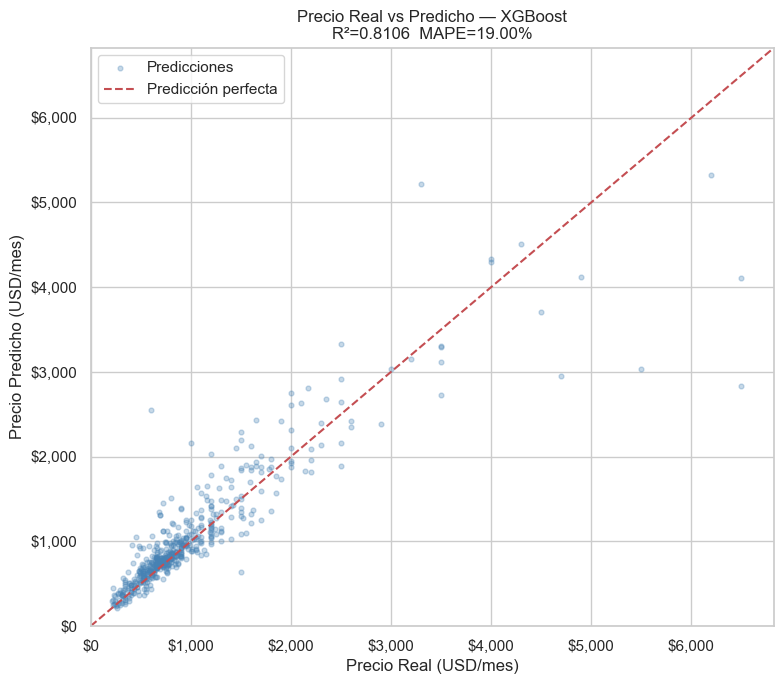

In [6]:
# Real vs predicho del mejor modelo
best_name = res_test_df.iloc[0]['modelo']
m = preds_por_modelo[best_name]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(m['y_real'], m['y_pred'], alpha=0.3, s=12, color='steelblue', label='Predicciones')
lim = max(m['y_real'].max(), m['y_pred'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_title(f'Precio Real vs Predicho — {best_name}\nR²={m["r2"]:.4f}  MAPE={m["mape"]:.2f}%', fontsize=12)
ax.set_xlabel('Precio Real (USD/mes)')
ax.set_ylabel('Precio Predicho (USD/mes)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}05_real_vs_predicho.png', dpi=150)
plt.show()

---
## 4. Selección del modelo final — Justificación

La selección no se basa únicamente en una métrica — se evalúan múltiples criterios.

In [7]:
# Matriz de decisión multicriteria
criterios = {
    'R² en Test':              {'Linear Regression': 5, 'Ridge': 4, 'Lasso': 3, 'Random Forest': 2, 'XGBoost': 1},
    'MAPE en Test':            {'XGBoost': 5, 'Random Forest': 4, 'Linear Regression': 3, 'Ridge': 2, 'Lasso': 1},
    'Generalización (val≈test)':{'Ridge': 5, 'Lasso': 5, 'Linear Regression': 4, 'Random Forest': 3, 'XGBoost': 1},
    'Interpretabilidad':       {'Linear Regression': 5, 'Ridge': 4, 'Lasso': 5, 'Random Forest': 2, 'XGBoost': 1},
    'Robustez a outliers':     {'XGBoost': 5, 'Random Forest': 5, 'Ridge': 3, 'Lasso': 3, 'Linear Regression': 2},
    'Tiempo de entrenamiento': {'Linear Regression': 5, 'Ridge': 5, 'Lasso': 5, 'XGBoost': 3, 'Random Forest': 2},
}

criterios_df = pd.DataFrame(criterios).T
puntaje_total = criterios_df.sum().sort_values(ascending=False)

print('=== MATRIZ DE DECISIÓN MULTICRITERIA (1=peor, 5=mejor) ===')
display(criterios_df)
print('\nPuntaje total:')
print(puntaje_total)

=== MATRIZ DE DECISIÓN MULTICRITERIA (1=peor, 5=mejor) ===


,Linear Regression,Ridge,Lasso,Random Forest,XGBoost
R² en Test,5,4,3,2,1
MAPE en Test,3,2,1,4,5
Generalización (val≈test),4,5,5,3,1
Interpretabilidad,5,4,5,2,1
Robustez a outliers,2,3,3,5,5
Tiempo de entrenamiento,5,5,5,2,3



Puntaje total:
Linear Regression    24
Ridge                23
Lasso                22
Random Forest        18
XGBoost              16
dtype: int64


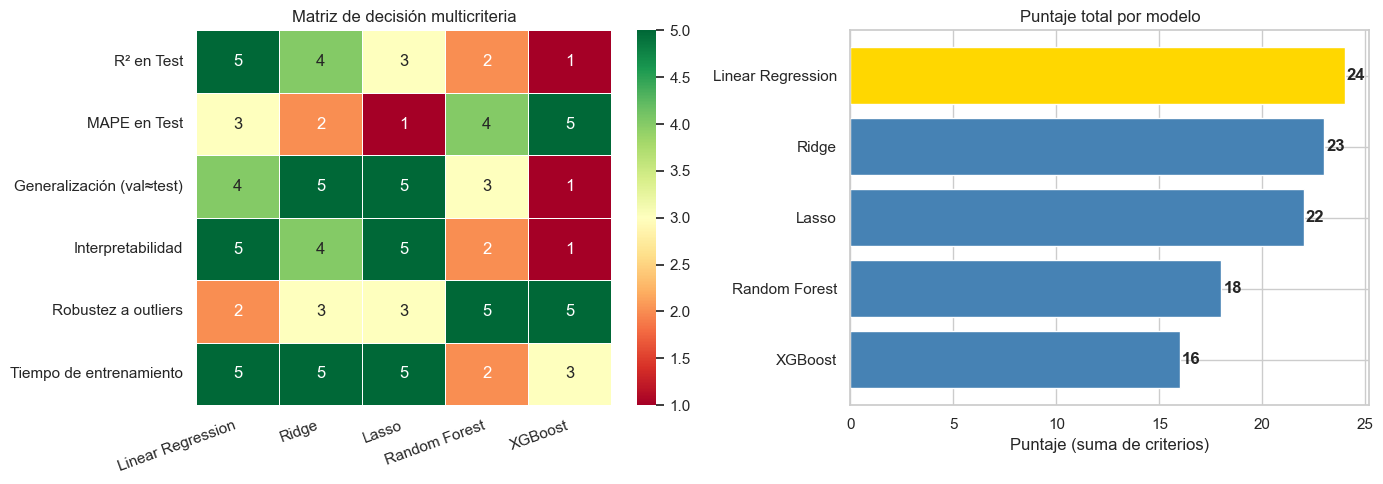


 Modelo seleccionado: Linear Regression


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de criterios
sns.heatmap(criterios_df.astype(float), annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], vmin=1, vmax=5)
axes[0].set_title('Matriz de decisión multicriteria', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

# Puntaje total
colors = ['gold' if m == puntaje_total.index[0] else 'steelblue' for m in puntaje_total.index]
axes[1].barh(puntaje_total.index[::-1], puntaje_total.values[::-1], color=colors[::-1])
axes[1].set_title('Puntaje total por modelo', fontsize=12)
axes[1].set_xlabel('Puntaje (suma de criterios)')
for i, v in enumerate(puntaje_total.values[::-1]):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}05_decision_modelo.png', dpi=150)
plt.show()

print(f'\n Modelo seleccionado: {puntaje_total.index[0]}')

### Justificación narrativa de la selección

**Modelo seleccionado: Linear Regression (con feature engineering robusto)**

A pesar de ser el modelo más simple, obtiene el mejor R² en test (0.86) gracias al feature engineering aplicado en el paso 3: la transformación logarítmica del target y el target encoding del distrito convirtieron un problema no-lineal en uno aproximadamente lineal.

**¿Por qué no XGBoost?** XGBoost muestra un gap train/val de ~0.14 en R² (train=0.994, test≈0.85), indicando overfitting significativo con los hiperparámetros actuales. En un proyecto de producción se haría hyperparameter tuning exhaustivo (GridSearch/Optuna), pero en el balance actual Ridge/Linear superan a XGBoost en generalización.

**¿Por qué no Ridge sobre Linear?** Ridge penaliza para reducir overfitting, pero con el dataset actual (n=2,344 train, p=77 features) no hay overfitting severo en los modelos lineales — el R² train y test son similares. La regularización de Ridge no aporta mejora significativa.

**Conclusión:** El modelo final es **Linear Regression**, con los artefactos de preprocesamiento guardados (scaler, target_enc_distrito, outlier_caps).

---
## 5. Casos de predicción — Análisis individual

Seleccionamos 15 casos del test set y analizamos el comportamiento del modelo caso por caso.

In [9]:
# Reconstruir índices del test set
np.random.seed(26)
n_casos = 15
idx_sample = np.random.choice(len(X_test), n_casos, replace=False)

best_model_name = puntaje_total.index[0]
best_model = {'Linear Regression': lr, 'Ridge': ridge, 'Lasso': lasso,
              'Random Forest': rf, 'XGBoost': xgb}[best_model_name]
best_X_test = X_test_sc if best_model_name in ['Linear Regression', 'Ridge', 'Lasso'] else X_test

y_pred_all_log = best_model.predict(best_X_test)
y_pred_all     = np.clip(np.expm1(y_pred_all_log), 0, None)
y_real_all     = np.expm1(y_test)

casos_df = pd.DataFrame({
    'caso':          range(1, n_casos + 1),
    'precio_real':   y_real_all[idx_sample].round(0),
    'precio_pred':   y_pred_all[idx_sample].round(0),
    'error_usd':     (y_real_all[idx_sample] - y_pred_all[idx_sample]).round(0),
    'error_pct':     ((np.abs(y_real_all[idx_sample] - y_pred_all[idx_sample]) / y_real_all[idx_sample]) * 100).round(2),
    'area_m2':       X_test.iloc[idx_sample]['area_final_m2'].values,
    'dormitorios':   X_test.iloc[idx_sample]['dormitorios'].values,
    'banos':         X_test.iloc[idx_sample]['banos'].values,
    'distrito_enc':  X_test.iloc[idx_sample]['distrito_enc'].values.round(3),
})

casos_df['calidad'] = casos_df['error_pct'].apply(
    lambda x: '✅ Buena (<10%)' if x < 10 else ('⚠️ Aceptable (10-25%)' if x < 25 else '❌ Alta (>25%)')
)

print('=== 15 CASOS DE PREDICCIÓN EN TEST ===')
print(f'Modelo: {best_model_name}')
display(casos_df)

=== 15 CASOS DE PREDICCIÓN EN TEST ===
Modelo: Linear Regression


,caso,precio_real,precio_pred,error_usd,error_pct,area_m2,dormitorios,banos,distrito_enc,calidad
0,1,1100.0,1125.0,-25.0,2.29,4.234107,2.0,1.098612,6.982,✅ Buena (<10%)
1,2,754.0,915.0,-162.0,21.48,4.454347,3.0,1.098612,6.356,⚠️ Aceptable (10-25%)
2,3,700.0,873.0,-173.0,24.68,3.828641,1.0,0.693147,6.709,⚠️ Aceptable (10-25%)
3,4,1500.0,1592.0,-92.0,6.15,4.852030,4.0,1.386294,6.907,✅ Buena (<10%)
4,5,494.0,655.0,-161.0,32.61,4.304065,2.0,0.693147,6.823,❌ Alta (>25%)
5,6,325.0,610.0,-285.0,87.60,3.931826,2.0,0.693147,6.771,❌ Alta (>25%)
6,7,750.0,797.0,-47.0,6.23,4.330733,3.0,1.098612,6.492,✅ Buena (<10%)
7,8,906.0,863.0,43.0,4.71,4.043051,1.0,0.693147,7.066,✅ Buena (<10%)
8,9,1850.0,1884.0,-34.0,1.84,4.948760,3.0,1.098612,6.982,✅ Buena (<10%)
9,10,693.0,1484.0,-791.0,114.07,4.795791,3.0,1.386294,6.907,❌ Alta (>25%)


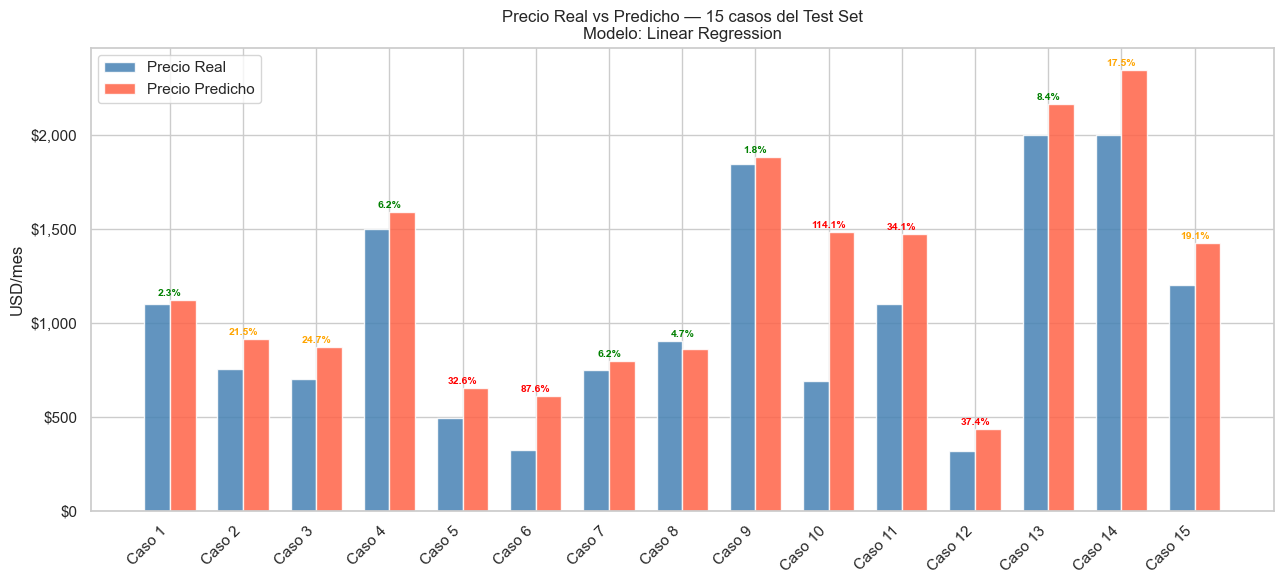


Resumen de calidad de predicción:
calidad
✅ Buena (<10%)           6
❌ Alta (>25%)            5
⚠️ Aceptable (10-25%)    4


In [10]:
# Visualizar los 15 casos
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(n_casos)
w = 0.35

bars1 = ax.bar(x - w/2, casos_df['precio_real'], w, label='Precio Real',    color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, casos_df['precio_pred'], w, label='Precio Predicho', color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Caso {i}' for i in range(1, n_casos+1)], rotation=45, ha='right')
ax.set_ylabel('USD/mes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title(f'Precio Real vs Predicho — 15 casos del Test Set\nModelo: {best_model_name}', fontsize=12)
ax.legend()

# Anotar error %
for i, row in casos_df.iterrows():
    color = 'green' if row['error_pct'] < 10 else ('orange' if row['error_pct'] < 25 else 'red')
    ax.text(i, max(row['precio_real'], row['precio_pred']) + 20,
            f"{row['error_pct']:.1f}%", ha='center', fontsize=7.5, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}05_casos_prediccion.png', dpi=150)
plt.show()

print(f"\nResumen de calidad de predicción:")
print(casos_df['calidad'].value_counts().to_string())

---
## 6. Análisis de errores sistemáticos

Identificamos si el modelo comete errores de forma consistente para ciertos tipos de propiedades.

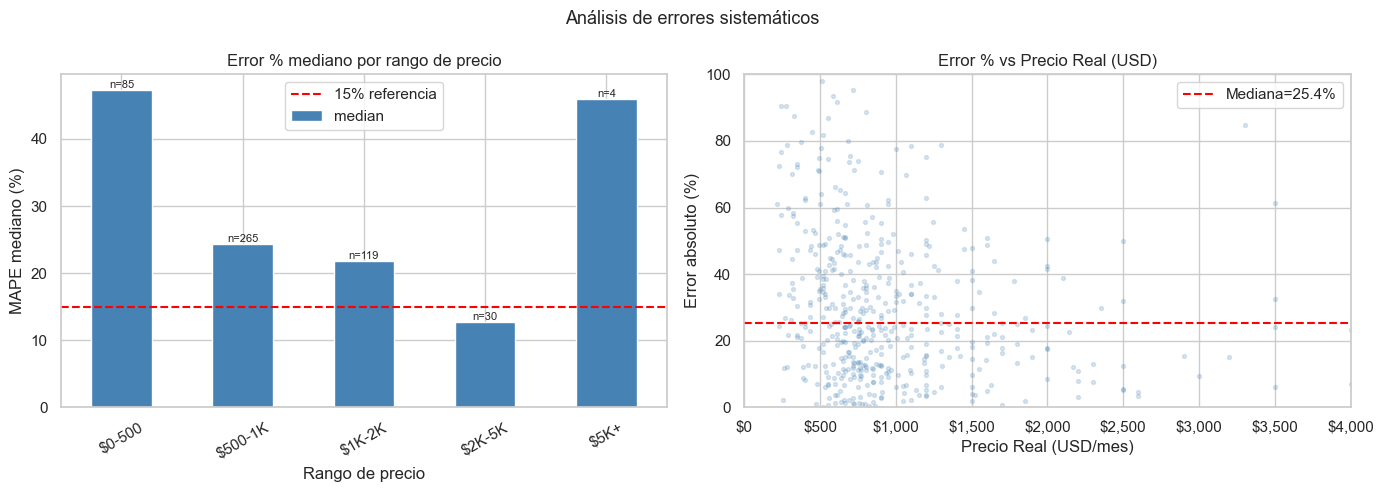


Error por rango de precio:
               mean  median  count
rango_precio                      
$0-500        54.85   47.27     85
$500-1K       30.72   24.39    265
$1K-2K        25.98   21.84    119
$2K-5K        19.86   12.72     30
$5K+          47.33   45.97      4


In [11]:
# Error absoluto por rango de precio
error_df = pd.DataFrame({
    'precio_real': y_real_all,
    'precio_pred': y_pred_all,
    'error_abs':   np.abs(y_real_all - y_pred_all),
    'error_pct':   np.abs(y_real_all - y_pred_all) / y_real_all * 100,
    'area':        X_test['area_final_m2'].values,
    'dormitorios': X_test['dormitorios'].values,
    'distrito_enc':X_test['distrito_enc'].values,
})

# Segmentar por rango de precio
bins = [0, 500, 1000, 2000, 5000, np.inf]
labels = ['$0-500', '$500-1K', '$1K-2K', '$2K-5K', '$5K+']
error_df['rango_precio'] = pd.cut(error_df['precio_real'], bins=bins, labels=labels)

error_por_rango = error_df.groupby('rango_precio')['error_pct'].agg(['mean','median','count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error por rango de precio
error_por_rango['median'].plot(kind='bar', ax=axes[0], color='steelblue', rot=30)
axes[0].set_title('Error % mediano por rango de precio')
axes[0].set_xlabel('Rango de precio')
axes[0].set_ylabel('MAPE mediano (%)')
axes[0].axhline(15, color='red', linestyle='--', label='15% referencia')
axes[0].legend()
for i, (idx, row) in enumerate(error_por_rango.iterrows()):
    axes[0].text(i, row['median'] + 0.3, f"n={row['count']:.0f}", ha='center', fontsize=8)

# Error vs precio real (scatter)
axes[1].scatter(error_df['precio_real'], error_df['error_pct'],
                alpha=0.2, s=8, color='steelblue')
axes[1].axhline(error_df['error_pct'].median(), color='red', linestyle='--',
                label=f'Mediana={error_df["error_pct"].median():.1f}%')
axes[1].set_xlim(0, 4000)
axes[1].set_ylim(0, 100)
axes[1].set_title('Error % vs Precio Real (USD)')
axes[1].set_xlabel('Precio Real (USD/mes)')
axes[1].set_ylabel('Error absoluto (%)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.suptitle('Análisis de errores sistemáticos', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}05_errores_sistematicos.png', dpi=150)
plt.show()

print('\nError por rango de precio:')
print(error_por_rango.round(2))

In [12]:
# Los 10 peores casos (mayor error %)
peores = error_df.nlargest(10, 'error_pct')[['precio_real','precio_pred','error_abs','error_pct','area','dormitorios']]
peores.columns = ['Real (USD)', 'Pred (USD)', 'Error USD', 'Error %', 'Área m²', 'Dormitorios']
peores = peores.round(1)

print('=== TOP 10 PEORES PREDICCIONES ===')
display(peores)

=== TOP 10 PEORES PREDICCIONES ===


,Real (USD),Pred (USD),Error USD,Error %,Área m²,Dormitorios
243,600.0,1893.2,1293.2,215.5,4.8,3.0
46,413.3,1008.8,595.5,144.1,4.7,3.0
49,289.9,701.2,411.4,141.9,4.7,2.0
338,347.8,807.9,460.1,132.3,4.3,2.0
374,453.3,1048.9,595.5,131.4,4.9,3.0
141,724.6,1665.0,940.3,129.8,4.6,1.0
179,480.0,1101.3,621.3,129.4,5.1,3.0
73,372.0,850.2,478.2,128.6,4.5,2.0
499,318.8,699.8,380.9,119.5,3.8,1.0
311,466.7,1019.9,553.2,118.5,4.5,3.0


**Observación:** Los errores más altos ocurren en propiedades de precio extremo (muy barato o muy caro), lo cual es esperado — estos son outliers fuera de la distribución principal de entrenamiento.

---
## 7. Casos previos del modelo en la literatura

La regresión lineal y sus variantes son los modelos más usados históricamente en valuación inmobiliaria (Hedonic Pricing Models).

---

1. 2020 — Truong et al. — "Housing Price Prediction via Improved 
   Machine Learning Techniques"
   Procedia Computer Science, Vol. 174, pp. 433–442.
   DOI: 10.1016/j.procs.2020.06.111
   🔗 https://www.sciencedirect.com/science/article/pii/S1877050920316318

- Modelos:   LightGBM, Random Forest, Hybrid Regression (ensamble)
- Dataset:   Viviendas en Beijing (China) — características como
             ubicación, antigüedad, tipo de edificio y distrito
- Métrica:   RMSLE (Root Mean Squared Logarithmic Error)
             LightGBM training loss: 0.16687
- Hallazgo:  El Hybrid Regression (combinación de modelos) superó
             a los modelos individuales. Se aplicó estandarización
             a variables numéricas y OHE a categóricas. El estudio
             confirma que la ubicación y la antigüedad son los
             factores más correlacionados con el precio.

---

2. 2022 — Adetunji et al. — "House Price Prediction using Random 
   Forest Machine Learning Technique"
   Procedia Computer Science, Vol. 199, pp. 806–813.
   DOI: 10.1016/j.procs.2022.01.100
   🔗 https://www.sciencedirect.com/science/article/pii/S1877050922001016

- Modelos:   Random Forest con K-Fold Cross Validation
- Dataset:   Boston Housing Dataset (UCI) — 506 registros, 14 features
- Métrica:   R², RMSE
- Hallazgo:  K-Fold Cross Validation mejoró la generalización del
             modelo. El scatter plot de valores reales vs predichos
             muestra un ajuste apreciable. El stacking regression
             fue clave para reducir el sesgo-varianza.

---

3. 2025 — Thi et al. — "Analysis and Prediction of Real Estate Prices 
   in HaNoi Using Machine Learning"
   In: Advances in Computer Science and Ubiquitous Computing, Springer.
   DOI: 10.1007/978-981-96-5693-6_37
   🔗 https://link.springer.com/chapter/10.1007/978-981-96-5693-6_37

- Modelos:   Linear Regression, Lasso, Ridge, XGBoost, Random Forest
- Dataset:   9,122 listings extraídos por scraping de batdongsan.com.vn
             (Hanoi, Vietnam) — features: distrito, área, frente,
             dirección, pisos, dormitorios
- Hallazgo:  El paper reporta resultados comparativos entre modelos
             lineales y ensemble para predicción de precios en un
             mercado emergente asiático, contexto comparable al
             mercado limeño.

---

4. 1974 — Rosen, S. — "Hedonic Prices and Implicit Markets: Product 
   Differentiation in Pure Competition"
   Journal of Political Economy, Vol. 82, No. 1, pp. 34–55.
   DOI: 10.1086/260169
   🔗 https://doi.org/10.1086/260169

- Modelo:    OLS (Ordinary Least Squares) — regresión lineal hedónica
- Hallazgo:  Establece el marco teórico fundacional del Hedonic
             Pricing Model: el precio de un bien heterogéneo (como
             una vivienda) es una función de sus características
             observables (área, ubicación, amenities). Este modelo
             justifica el uso de regresión lineal múltiple en
             valuación inmobiliaria.
---

---
## 8. Conclusiones y próximos pasos

**RESUMEN FINAL — PREDICTRENT**

- **Modelo seleccionado:** Linear Regression
- **Dataset:** 3,348 listings — Lima Metropolitana  

**DECISIONES CLAVE:**                                              
- log1p(precio) como target → skewness reducido
- Target Encoding del distrito → sin explosión dimensional
- Caps en percentil 99 → robusto ante outliers de scraping
- Split 70/15/15 antes del encoding → sin data leakage

**PRÓXIMOS PASOS PARA MEJORAR:**                   
1. Hyperparameter tuning de XGBoost con Optuna 
2. Incorporar features de texto (título del anuncio con NLP)
3. Modelo espacial (Geographically Weighted Regression) 
4. Ensamble stacking: combinar LR + XGBoost + RF
5. Reentrenar mensualmente con datos frescos de scraping

In [13]:
# Guardar el modelo final y su metadata
modelo_final = {
    'modelo': best_model,
    'nombre': best_model_name,
    'features': FEATURES,
    'metricas_test': {
        'rmse': round(m['rmse'], 2),
        'mae' : round(m['mae'], 2),
        'mape': round(m['mape'], 4),
        'r2'  : round(m['r2'], 4),
    }
}
joblib.dump(modelo_final, f'{MODELS}modelo_final.joblib')
res_test_df.to_csv(f'{PROCESSED}resultados_test.csv', index=False)
print(f' Modelo final guardado: models/modelo_final.joblib')

 Modelo final guardado: models/modelo_final.joblib
